## **第一周学习汇报**

本周完成了 PyTorch 环境搭建，掌握了tensor基本操作、数据预处理、matplotlib函数绘图与自动求导，在此基础上参考既有资料实操了**线性回归的代码实现**，并围绕**小批量 SGD 的学习率与 epoch 调参**做了对比实验。

## **基本进度说明**

1. 理解tensor的基本概念，掌握了矩阵计数、重塑形与合并等操作

In [1]:
import torch
x=torch.arange(12)
print(x)
x.numel()
x.reshape(3,4)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])


tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

In [2]:
x=torch.arange(12,dtype=torch.float32).reshape(3,4)
y=torch.tensor([[2.0,1,4,3],[1,2,3,4],[4,3,2,1]])
torch.cat((x,y),dim=0),torch.cat((x,y),dim=1) #merge by row and column separately

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [ 2.,  1.,  4.,  3.],
         [ 1.,  2.,  3.,  4.],
         [ 4.,  3.,  2.,  1.]]),
 tensor([[ 0.,  1.,  2.,  3.,  2.,  1.,  4.,  3.],
         [ 4.,  5.,  6.,  7.,  1.,  2.,  3.,  4.],
         [ 8.,  9., 10., 11.,  4.,  3.,  2.,  1.]]))

2. 实操了利用os和pandas库进行制表、数据切分等数据预处理的过程

In [3]:
import os
import pandas as pd

os.makedirs('data',exist_ok=True)
data_file=os.path.join('data','house_tiny.csv')
with open(data_file,'w') as f:
    f.write('NumRooms,Alley,Price\n')
    f.write('NA,Pave,127500\n')
    f.write('2,NA,106000\n')
    f.write('4,NA,178100\n')
    f.write('NA,NA,140000\n')

data=pd.read_csv(data_file)
print(data)

   NumRooms Alley   Price
0       NaN  Pave  127500
1       2.0   NaN  106000
2       4.0   NaN  178100
3       NaN   NaN  140000


In [4]:
inputs,outputs=data.iloc[:,0:2],data.iloc[:,2]
# separate numerical column and classification column
num_cols = ['NumRooms']          # or inputs.select_dtypes(include=['float','int']).columns

# fill the numerical column with the mean value
inputs[num_cols] = inputs[num_cols].fillna(inputs[num_cols].mean())
print(inputs)

   NumRooms Alley
0       3.0  Pave
1       2.0   NaN
2       4.0   NaN
3       3.0   NaN


In [5]:
inputs=pd.get_dummies(inputs,dummy_na=True)
print(inputs)

   NumRooms  Alley_Pave  Alley_nan
0       3.0        True      False
1       2.0       False       True
2       4.0       False       True
3       3.0       False       True


3. 实操了matplotlib函数绘图与tensor自动求导，并将二者结合用于数值分析

In [6]:
import torch
#change requires_grad parameter along with creating tensor
x=torch.arange(4.0,requires_grad=True)  
y=2*torch.dot(x,x) #y=2X.T*X
y.backward() #backpropagate
x.grad

tensor([ 0.,  4.,  8., 12.])

In [7]:
x.grad==4*x

tensor([True, True, True, True])

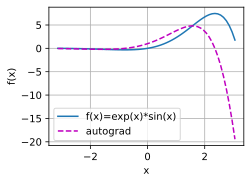

In [9]:
import torch
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l
def f(x):
    return torch.sin(x)*torch.exp(x)
x=torch.arange(-1*np.pi,1*np.pi,0.1,requires_grad=True)

y=f(x)
# keep the gradient in the same shape as the original matrix
y.backward(torch.ones_like(y))  
dy_dx=x.grad

d2l.plot(x.detach().numpy(),[y.detach().numpy(),dy_dx.detach().numpy()],'x','f(x)',legend=['f(x)=exp(x)*sin(x)','autograd'])

## **核心实验说明**

1.实操小批量随机梯度下降的代码实现

（1）导入相关库

In [10]:
from matplotlib_inline import backend_inline 
import random
import torch
from d2l import torch as d2l

（2）利用正态分布生成特征X的随机样本集，并在其中**添加噪声∊以模拟现实情况**，进而得到标签y的样本集，其中特征X具有两个分量

In [12]:
def synthetic_data(w,b,num_examples):  #@save
    #create y=Xw+b+∊
    X=torch.normal(0,1,(num_examples,len(w)))
    y=torch.matmul(X,w)+b #calculate theoretical value
    y+=torch.normal(0,0.1,y.shape)  #collect random error
    return X,y.reshape((-1,1))

（3）给出权重w和偏置b的真实值，同时分别绘制出特征分量x1和x2与标签y的散点图，此处X为一个1000*2的矩阵

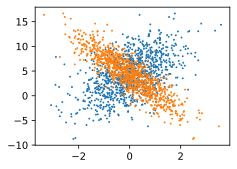

In [13]:
true_w=torch.tensor([2,-3.4])
true_b=4.2
features,labels=synthetic_data(true_w,true_b,1000)  

d2l.set_figsize()
d2l.plt.scatter(features[:,0].detach().numpy(),labels.detach().numpy(),1)
d2l.plt.scatter(features[:,1].detach().numpy(),labels.detach().numpy(),1)

（4）切分样本集，从而便于后续对小批量数据进行一次梯度下降，**便于平衡学习速度与稳定性**；同时**打乱了索引列表，避免模型学习无意义的顺序信息**

In [16]:
def data_iter(batch_size,features,labels):  #@save
    num_examples=len(features)
    indices=list(range(num_examples))
    #randomly read minibatch examples, that is, without specific order
    random.shuffle(indices)  #shuffle the index set
    for i in range(0,num_examples,batch_size):
        batch_indices=torch.tensor(indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]  #return a batch of data for each request

（5）确定小批量数据大小为10，生成随机的权重w和偏置b，构建**线性回归模型、损失函数和梯度下降算法**

In [17]:
batch_size=10
w=torch.normal(0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)

def linreg(X,w,b):  #@save
    #linear regression model
    return torch.matmul(X,w)+b

def squared_loss(y_est,y):  #@save
    return (y_est-y.reshape(y_est.shape))**2/2

def sgd(params,learning_rate,batch_size):  #@save
    #stochastic gradient descent
    with torch.no_grad():
        for param in params:
            param-=learning_rate*param.grad/batch_size
            param.grad.zero_()

此处权重w服从均值为0，标准差为0.01的正态分布，距离真实值不远

（6）进行梯度下降循环，此处学习率设为0.03，epoch数设为3

In [18]:
learning_rate=0.03
num_epochs=3
net=linreg
loss=squared_loss
for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l=loss(net(X,w,b),y)
        l.sum().backward()
        sgd([w,b],learning_rate,batch_size)
    with torch.no_grad():
        train_loss=loss(net(features,w,b),labels)
        print(f'epoch {epoch+1},loss: {float(train_loss.mean()):f}\n')

print(f'estimated error of w: {true_w-w.reshape(true_w.shape)}')
print(f'estimated error of b: {true_b-b}')

epoch 1,loss: 0.034234

epoch 2,loss: 0.005240

epoch 3,loss: 0.005132

estimated error of w: tensor([0.0009, 0.0007], grad_fn=<SubBackward0>)
estimated error of b: tensor([0.0029], grad_fn=<RsubBackward1>)


注意到模型在到达epoch 2时**已十分接近0.005的理想损失**，这是由于**初始学习率较大**且**权重w和偏置b与真实值之间的距离不大**，因此模型能在较短时间内接近最优参数

2.Mini-batch SGD学习率与epoch调参的对比实验

在实验1的基础上，我试图通过调整学习率和epoch参量对比分析出**如何设定合理的SGD模型超参数**

（1）更改训练函数，使之能够返回每个epoch的平均loss

In [19]:
def train(lr, num_epochs, batch_size=10):
    # reinitialize parameters for each experiment to ensure fair comparison
    w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    
    loss_history = []   # record the average loss for each epoch
    
    for epoch in range(num_epochs):
        total_loss = 0.0
        num_batches = 0
        for X, y in data_iter(batch_size, features, labels):
            y_hat = X @ w + b                          
            loss = ((y_hat - y) ** 2 / 2).mean()       
            loss.backward()                            
            with torch.no_grad():
                w -= lr * w.grad
                b -= lr * b.grad
                w.grad.zero_()
                b.grad.zero_()
            
            total_loss += loss.item()
            num_batches += 1
        
        avg_loss = total_loss / num_batches
        loss_history.append(avg_loss)
    
    return loss_history, w.detach(), b.detach()

（2）固定epoch，更改学习率，并绘出loss下降曲线

lr=0.001 | At last w=[1.3489105701446533, -2.2313759326934814], b=2.683
lr= 0.03 | At last w=[1.9971951246261597, -3.3982982635498047], b=4.201
lr=  0.3 | At last w=[1.9911195039749146, -3.3963027000427246], b=4.219


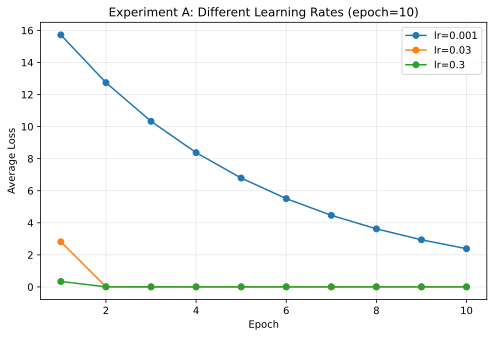

In [38]:
lrs = [0.001, 0.03,0.3]
num_epochs_A = 10

d2l.plt.figure(figsize=(8, 5))
for lr in lrs:
    loss_hist, w_final, b_final = train(lr, num_epochs_A)
    d2l.plt.plot(range(1, num_epochs_A + 1), loss_hist, marker='o', label=f'lr={lr}')
    print(f"lr={lr:5} | At last w={w_final.flatten().tolist()}, b={b_final.item():.3f}")

d2l.plt.xlabel('Epoch')
d2l.plt.ylabel('Average Loss')
d2l.plt.title('Experiment A: Different Learning Rates (epoch=10)')
d2l.plt.legend()
d2l.plt.grid(True, alpha=0.3)
d2l.plt.show()

查阅资料后发现，尽管学习率取0.3时模型拟合速度很快，但对于更大规模的数据集，随着epoch逐渐增多，模型有过拟合风险，因此该实验中的理想学习率为0.03

（3）固定学习率，更改epoch，并绘出loss下降曲线

epoch= 1 | 最终 w=[0.2099241465330124, -0.3495608866214752], b=0.407
epoch= 3 | 最终 w=[0.5720057487487793, -0.9318469762802124], b=1.106
epoch=10 | 最终 w=[1.3449846506118774, -2.2298123836517334], b=2.683


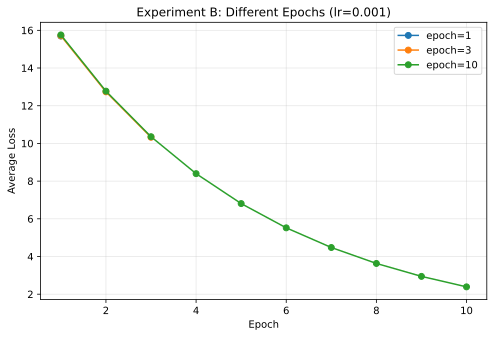

In [35]:
lr_B = 0.001
epochs_list = [1, 3, 10]

d2l.plt.figure(figsize=(8, 5))
for ep in epochs_list:
    loss_hist, w_final, b_final = train(lr_B, ep)
    d2l.plt.plot(range(1, ep + 1), loss_hist, marker='o', label=f'epoch={ep}')
    print(f"epoch={ep:2} | 最终 w={w_final.flatten().tolist()}, b={b_final.item():.3f}")

d2l.plt.xlabel('Epoch')
d2l.plt.ylabel('Average Loss')
d2l.plt.title(f'Experiment B: Different Epochs (lr={lr_B})')
d2l.plt.legend()
d2l.plt.grid(True, alpha=0.3)
d2l.plt.show()

loss随着epoch增多稳定下降，但同时单次梯度下降的收益递减，使得模型的运行效率下降

进一步查阅资料，了解到对于**线性回归和小型网络**而言，学习率**通常以0.01到0.1为起点**；而对于深度学习网络，学习率**一般在1e-4到1e-2之间**

# 下周计划

1.简化线性回归的代码实现 
2.学习**softmax回归**和**多层感知机**并同样利用代码进行实现 
3.了解过拟合与欠拟合等基础概念